In [1]:
# Import necessary libraries for numerical and data operations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import feature extraction tools for converting text to numeric format
from sklearn.feature_extraction.text import TfidfVectorizer

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import the SVM model for classification
from sklearn.svm import SVC

# Import performance metrics and tools to evaluate classification models
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Import a custom function (written in your own module) for text cleaning and preprocessing
from data_preprocessing_module import preprocess_text


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aavas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aavas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('datasets/changed/data_news_1.csv')

# Handle missing values in the 'source' column by replacing them with "Unknown"
df['source'] = df['source'].fillna('Unknown')

# Apply your custom text preprocessing function to each news title and text
df['title_clean'] = df['title'].apply(preprocess_text)
df['text_clean'] = df['text'].apply(preprocess_text)

# Define the target variable (label), which indicates whether a news title is 'Fake' or 'Real'
y = df['type_of_news']

In [3]:
def train_and_evaluate(vectorizer, name, feature_column):
    """
    Trains an SVM model using the specified vectorizer with bootstrapping,
    evaluates performance, and returns the trained vectorizer, model, and
    bootstrapped accuracies.
    """
    # Convert text data to numerical feature matrix
    X = vectorizer.fit_transform(df[feature_column])

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Bootstrapping: simulate training multiple times with resampling
    bootstrap_accuracies = []
    for _ in range(100):
        indices = np.random.choice(range(X_train.shape[0]), size=X_train.shape[0], replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = np.array(y_train)[indices]

        model = SVC(kernel='linear', probability=True)
        model.fit(X_bootstrap, y_bootstrap)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        bootstrap_accuracies.append(acc)

    # Final model training
    final_model = SVC(kernel='linear', probability=True)
    final_model.fit(X_train, y_train)

    y_pred_final = final_model.predict(X_test)
    final_accuracy = accuracy_score(y_test, y_pred_final)
    conf_matrix = confusion_matrix(y_test, y_pred_final, labels=['Fake', 'Real'])
    class_report = classification_report(y_test, y_pred_final, zero_division=0)

    # Confidence interval
    bootstrap_mean = np.mean(bootstrap_accuracies)
    conf_int_95 = (
        np.percentile(bootstrap_accuracies, 2.5),
        np.percentile(bootstrap_accuracies, 97.5)
    )

    # Display results
    print(f"\n--- Results for {name} ---")
    print(f"Final SVM Accuracy: {final_accuracy:.4f}")
    print(f"Mean Bootstrapped Accuracy: {bootstrap_mean:.4f}")
    print(f"95% Confidence Interval: [{conf_int_95[0]:.4f}, {conf_int_95[1]:.4f}]")
    print("Classification Report:\n", class_report)

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Fake', 'Real'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    # Histogram of accuracies
    plt.figure(figsize=(8, 5))
    plt.hist(bootstrap_accuracies, bins=15, color='skyblue', edgecolor='black')
    plt.axvline(bootstrap_mean, color='red', linestyle='dashed', label=f"Mean: {bootstrap_mean:.4f}")
    plt.axvline(conf_int_95[0], color='green', linestyle='dotted', label=f"2.5%: {conf_int_95[0]:.4f}")
    plt.axvline(conf_int_95[1], color='green', linestyle='dotted', label=f"97.5%: {conf_int_95[1]:.4f}")
    plt.title(f"Bootstrapped Accuracies ({name})")
    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    return vectorizer, final_model, bootstrap_accuracies


--- Results for TfidfVectorizer (Title) ---
Final SVM Accuracy: 0.6486
Mean Bootstrapped Accuracy: 0.6378
95% Confidence Interval: [0.5405, 0.7297]
Classification Report:
               precision    recall  f1-score   support

        Fake       0.67      0.63      0.65        19
        Real       0.63      0.67      0.65        18

    accuracy                           0.65        37
   macro avg       0.65      0.65      0.65        37
weighted avg       0.65      0.65      0.65        37



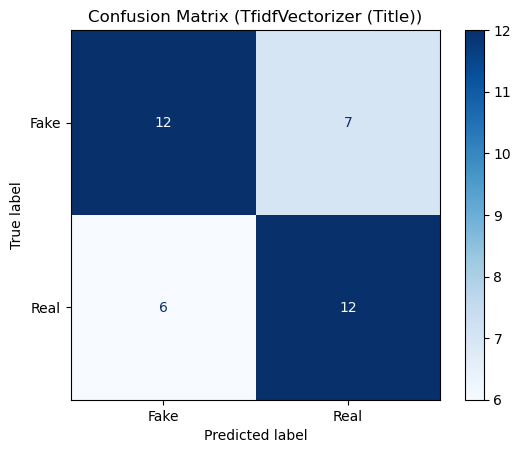

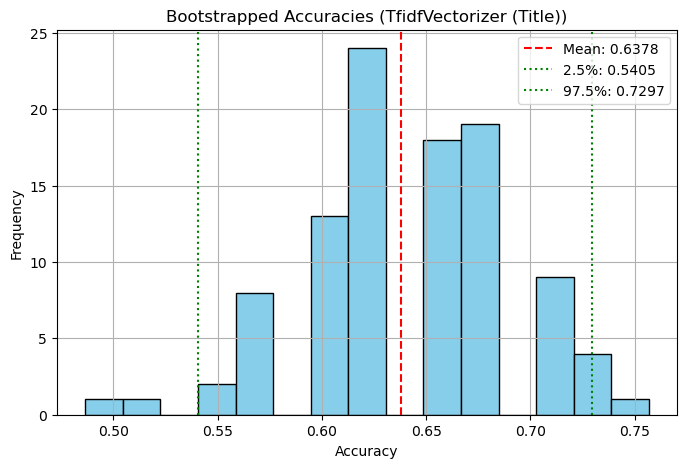

In [4]:
# Train and evaluate using TF-IDF on title
tfidf_vectorizer_title = TfidfVectorizer()
vectorizer_tfidf_title, model_tfidf_title, bootstrap_accuracies_tfidf_title = train_and_evaluate(
    tfidf_vectorizer_title, 'TfidfVectorizer (Title)', 'title_clean'
)

In [ ]:
# Train and evaluate using TF-IDF on text
tfidf_vectorizer_text = TfidfVectorizer()
vectorizer_tfidf_text, model_tfidf_text, bootstrap_accuracies_tfidf_text = train_and_evaluate(
    tfidf_vectorizer_text, 'TfidfVectorizer (Text)', 'text_clean'
)

In [ ]:
# Model selection and accuracy display
print(f"\nUsing best performing model for title: TfidfVectorizer (Accuracy: {np.mean(bootstrap_accuracies_tfidf_title):.4f})")
print(f"\nUsing best performing model for text: TfidfVectorizer (Accuracy: {np.mean(bootstrap_accuracies_tfidf_text):.4f})")

In [ ]:
# User input for prediction
user_title = input("\nEnter news title to classify: ")
cleaned_title = preprocess_text(user_title)
user_vector_title = vectorizer_tfidf_title.transform([cleaned_title])
prediction_title = model_tfidf_title.predict(user_vector_title)
print("Prediction (Title):", prediction_title[0])

In [ ]:
user_text = input("\nEnter news text to classify: ")
cleaned_text = preprocess_text(user_text)
user_vector_text = vectorizer_tfidf_text.transform([cleaned_text])
prediction_text = model_tfidf_text.predict(user_vector_text)
print("Prediction (Text):", prediction_text[0])